# 0. Introduction

Our goal here is to use 3 machine learning methods for classification, to try and use all features to predict correctly the label.
In this `decision_tree` file, we'll apply a Decision Tree method.

This is done onto a specific dataset, which correspond to a subset of the <a href="https://www.cdc.gov/brfss/annual_data/annual_2014.html">"CDC Diabetes Health Indicators"</a> dataset.
This subset was found on <a href= "https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators">"UC Irvine Machine Learning Repository"</a> and was downloaded on <a href="https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data">"Kaggle"</a>.

This subset is balanced and contains 70,692 survey responses about 21 variables.
Informations about those variables were given, and a codenotebook can be found on the CDC webpage.
The target classification is binary : 0 means non-diabetic, and 1 means pre-diabetic or diabetic.

# 1. Preparation

## 1.1. Libraries

To make a decision tree, three packages were imported for easier data importation and manipulation :

- csv,

- pandas,

- numpy.

In [1]:
# libraries
import csv # for easier import of data from csv file
import pandas as pd # for easier data manipulation and visualisation
import numpy as np # used by panda : for easier data manipulation too, for math log

## 1.2. Data Importation

This importation is done via `csv` package, putting each row into dictionaries in which each key correspond to a column title.
Through manipulation we then organise all imported data into a `pandas.DataFrame` made to correspond to the original file organisation. As such, all columns have the original .csv file's header.

In [2]:
# Data import
data_dict = {}
with open('./data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv') as f:
    header = [h for h in next(f).split(",")]
    for name in header:
        data_dict[name] = []
    scores = csv.DictReader(f, fieldnames = header)
    for row in scores:
        for name, value in row.items():
            data_dict[name].append(value) 

df_raw = pd.DataFrame(data_dict, columns=header)

## 1.2. Data Manipulation

Since we have background knowledge to our data, we could discretise it based on that knowledge.
This could allow to make our Decision Tree faster.

Among all of our data, we have quite a lot of booleans data, as well as some numerical data.
This numerical data is discretised in integer, and correspond to BMI, GenHlth, MenHlth, PhysHlth, Age, Education, and Income.
Among those, some were already categorised into smaller intervalles (e.g. Income).
But BMI, MenHlth and PhysHlth still vary between 12 to 80, or 0 to 30.
That's why those seem worth simplifying into :

*   BMI : converted into 5 subclasses based on the World Health Organization.
    *   $0 < \text{Underweight} \le 18.5$
    *   $18.5 < \text{Normal weight} \le 25$
    *   $25 < \text{Overweight} \le 30$
    *   $30 < \text{Obesity I} \le 35$
    *   $35 < \text{Obesity II}$

*   MentHlth and PhysHlth : converted into 4 intervalles corresponding to passing weeks. 
    *   0 = 0-7 day  |  1 = 8-14 days  |  2 = 15-21 days  |  3 = 22-30 days

The resulting sample division can be visualised below.

### 1.2.1. Little Data Visualisation

To go with our decision, here is some data visualisation.
This shows all the unique values found in our data.

In [3]:
display(df_raw.describe())

for key in header:
    print(key, sorted(pd.unique(df_raw[key])))

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income\n
count,70692,70692,70692,70692,70692,70692,70692,70692,70692,70692,...,70692,70692,70692,70692,70692,70692,70692,70692,70692,70692
unique,2,2,2,2,80,2,2,2,2,2,...,2,2,5,31,31,2,2,13,6,8
top,0.0,1.0,1.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
freq,35346,39832,37163,68943,6327,37094,66297,60243,49699,43249,...,67508,64053,23427,48091,39915,52826,38386,10856,26020,20646


Diabetes_binary ['0.0', '1.0']
HighBP ['0.0', '1.0']
HighChol ['0.0', '1.0']
CholCheck ['0.0', '1.0']
BMI ['12.0', '13.0', '14.0', '15.0', '16.0', '17.0', '18.0', '19.0', '20.0', '21.0', '22.0', '23.0', '24.0', '25.0', '26.0', '27.0', '28.0', '29.0', '30.0', '31.0', '32.0', '33.0', '34.0', '35.0', '36.0', '37.0', '38.0', '39.0', '40.0', '41.0', '42.0', '43.0', '44.0', '45.0', '46.0', '47.0', '48.0', '49.0', '50.0', '51.0', '52.0', '53.0', '54.0', '55.0', '56.0', '57.0', '58.0', '59.0', '60.0', '61.0', '62.0', '63.0', '64.0', '65.0', '66.0', '67.0', '68.0', '69.0', '70.0', '71.0', '72.0', '73.0', '74.0', '75.0', '76.0', '77.0', '78.0', '79.0', '80.0', '81.0', '82.0', '83.0', '84.0', '85.0', '86.0', '87.0', '89.0', '92.0', '95.0', '98.0']
Smoker ['0.0', '1.0']
Stroke ['0.0', '1.0']
HeartDiseaseorAttack ['0.0', '1.0']
PhysActivity ['0.0', '1.0']
Fruits ['0.0', '1.0']
Veggies ['0.0', '1.0']
HvyAlcoholConsump ['0.0', '1.0']
AnyHealthcare ['0.0', '1.0']
NoDocbcCost ['0.0', '1.0']
GenHlth ['1

### 1.2.2. Data Transformation

In [4]:
df = df_raw.astype(float) # to be able to use it in math conditions

# divide the BMI values into 5 sub classes from the OMS
def disc_bmi(x):
    if x <= 18.5:    
        return 0
    elif x <= 25:  
        return 1
    elif x <= 30: 
        return 2
    elif x <= 35:         
        return 3
    else:
        return 4
    
df['BMI'] = df['BMI'].apply(disc_bmi)

# divide the MentHlth and PhysHlthinto features into 4 sub classes. 0:'0-7 day', 1:'8-14 days', 2:'15-21 days', 3:'22-30 days'
def disc_days(x):
    if x < 8:    
        return 0
    elif x < 15:  
        return 1
    elif x < 22: 
        return 2
    else:         
        return 3

df['MentHlth'] = df['MentHlth'].apply(disc_days)
df['PhysHlth'] = df['PhysHlth'].apply(disc_days)

df = df.astype(int) # all data are integers

# Transformation of boolean variables into booleans
df_unique = df_raw.describe().loc["unique"]
bool_columns = df_raw.loc[:, df_unique == 2].columns
df[bool_columns] = df[bool_columns].astype(bool)

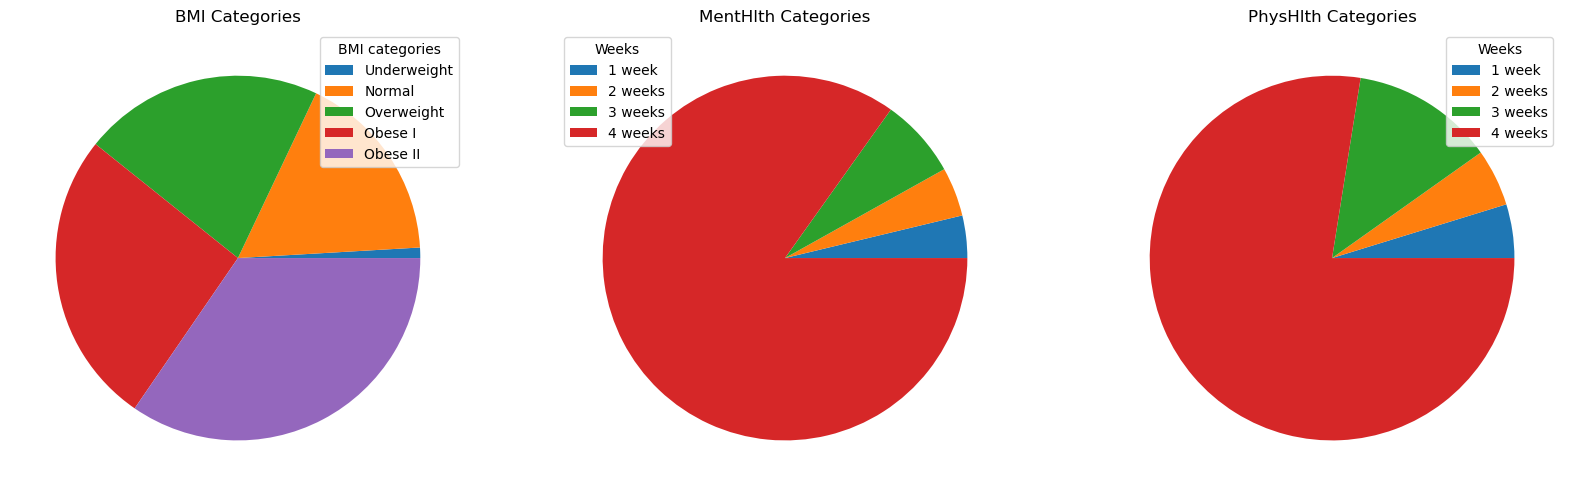

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(20, 10))
counts = sorted(df["BMI"].value_counts())
count_categories = ["Underweight", "Normal", "Overweight", "Obese I", "Obese II"]
ax[0].pie(counts)
ax[0].set_title("BMI Categories")
ax[0].legend(title = "BMI categories", labels = count_categories)

counts = sorted(df["MentHlth"].value_counts())
count_categories = ["1 week", "2 weeks", "3 weeks", "4 weeks"]
ax[1].pie(counts)
ax[1].set_title("MentHlth Categories")
ax[1].legend(title = "Weeks", labels = count_categories)

counts = sorted(df["PhysHlth"].value_counts())
count_categories = ["1 week", "2 weeks", "3 weeks", "4 weeks"]
ax[2].pie(counts)
ax[2].set_title("PhysHlth Categories")
ax[2].legend(title = "Weeks", labels = count_categories)

plt.show() 

### 1.2.3. Data Split

To be able to test our Decision Tree onto unknown data, we have splitted our initial training data into training and validation data.
For better training, we have kept our training data balanced.
This was easy since our initial dataset was already based with 50-50 `Diabetes_binary` target tags.
But since they were organised with first `0` (Non-diabetic) and then `1`(Diabetic), we didn't just split our data as such. 
We first shuffled our dataset before slitting it to make it, so that even if it isn't always perfect, it will randomise our sampling and should give out balanced data subsets.

In [6]:
def split_train_test(df, seed=42):
    # splitting the dataframe into two parts, using proportions 8:2 for training:validation

    np.random.seed(seed)
    shuffled_df = df.sample(frac=1).reset_index(drop=True)

    train_df = shuffled_df.iloc[:(int(len(shuffled_df) * (8 / 10)))].copy()
    val_df = shuffled_df.iloc[int(len(shuffled_df) * (8 / 10)):].copy()

    return train_df, val_df

In [7]:
# get testing and training data
train, test = split_train_test(df)
# important to reset indexes because predictions use them
train = train.reset_index(drop = True)
test = test.reset_index(drop = True)

As seen here below, our training and testing sets (generated with seed 42) are balanced.

In [8]:
display(train["Diabetes_binary"].value_counts())

Diabetes_binary
True     28368
False    28185
Name: count, dtype: int64

# 2. Decision Tree

## 2.1. Training

The first step to using a Decision Tree for classification, is to make this tree and make it usable / explorable.
For this, we have taken inspiration from our 2025-2026 ULB course "INFO-F410 - Techniques of Artificial Intelligence" given by Dr. SACHARIDIS Dimitri.
The pseudo-code below was used as inspiration for our code, and comes from the up-mention course.

<figure>
<img src="Capture d’écran 2026-05-10 à 16.57.13.png">
</figure>

In [9]:
print(df["Diabetes_binary"].value_counts().index)

Index([False, True], dtype='bool', name='Diabetes_binary')


In [10]:
def decision_tree(samples, features_set, numerical_columns, default=0):
    label = "Diabetes_binary"
    # end conditions
    if not isinstance(features_set, set):
        features_set = set(features_set)
    if len(samples) == 0:
        return default
    elif len(pd.unique(samples[label])) == 1:
        return int(samples[label].iloc[0])
    elif len(features_set) == 0:
        return leaf_classification(samples, label)
    
    # choose feature to split branches
    best_attribute, samples_per_value = choose_attribute(samples, features_set, numerical_columns)
    if not best_attribute: # end condition
        return leaf_classification(samples, label)

    # subtree creation
    tree = {best_attribute: {}}
    for value, new_samples in samples_per_value.items():
        subtree = decision_tree(new_samples, features_set - set([best_attribute]), numerical_columns, default)
        tree[best_attribute][value] = subtree
    
    return tree

def leaf_classification(samples, label):
    total = len(samples)
    counts = samples[label].value_counts()
    tag_counts = counts.iloc[0]
    if counts.index[0]:
        return tag_counts / total
    else:
        return (total - tag_counts) / total


# feature selection functions :
# 1. feature selection criterion = entropy -> information gain
def entropy(samples):
    """Compute information entropy of a given node"""
    result = 0
    total = len(samples)
    for count in samples["Diabetes_binary"].value_counts():
        if count > 0:
            proba = count / total
            result += -proba * np.log2(proba)
    return result

# 1. feature selection criterion = entropy -> information gain
def information_gain(parent, children):
    """Compute information gain of a given branch split"""
    total = len(parent)
    parent_entropy = entropy(parent)
    weigted_children_entropies = []
    children_information = 0
    for child_sample in children.values():
        child_weigth = len(child_sample) / total
        child_entropy = entropy(child_sample)
        weigted_children_entropies.append(child_weigth * child_entropy)
    for term in weigted_children_entropies:
        children_information += term
    return parent_entropy - children_information

# 2. feature selection loop (!= depending on numerical or boolean)
def choose_attribute(samples, features_set, numerical_columns):
    """Find best feature to start a new subtree from"""
    best_attribute = None
    best_gain = 0
    best_samples_per_value = {}
    for feature in features_set:
        if feature in numerical_columns:
            samples_per_value, gain = best_average(feature, samples)
        else:
            samples_per_value = {}
            for value in pd.unique(samples[feature]):
                new_sample = samples[samples[feature] == value]
                samples_per_value[value] = new_sample
            gain = information_gain(samples, samples_per_value)
        if best_gain < gain:
            best_attribute = feature
            best_gain = gain
            best_samples_per_value = samples_per_value
    return best_attribute, best_samples_per_value

def best_average(feature, samples):
    """Find best threshold to split in 2 a numerical variable"""
    best = [None, 0]
    unique_values = pd.unique(
        samples[feature].sort_values(axis=0).reset_index(drop=True)
    )
    if len(unique_values) > 0:
        for i in range(len(unique_values) - 1):
            children_per_value = {}
            i_average = (unique_values[i] + unique_values[i + 1]) / 2
            left = samples[samples[feature] < i_average]
            right = samples[samples[feature] >= i_average]
            children_per_value[("<", i_average)] = left
            children_per_value[(">=", i_average)] = right
            i_gain = information_gain(samples, children_per_value)
            if i_gain > best[-1]:
                best = [children_per_value, i_gain]
    return best

In [11]:
features_list = header[1:]
numerical_columns = df.describe().columns
tree = decision_tree(train, features_list, numerical_columns)

## 2.2. Testing Predictions

### 2.2.1. Predicting

In [12]:
def predict(tree, test, y, threshold=0.5):
    """Classification predictions from trained tree"""
    for feature, branches in tree.items():
        for key, subtree in branches.items():
            if isinstance(subtree, dict):
                if isinstance(key, tuple):
                    operator, value = key
                    if operator == '<':
                        cond = test[feature] < value
                    else:
                        cond = test[feature] >= value
                else:
                    cond = test[feature] == key
                predict(subtree, test[cond], y, threshold)
            else:
                y.loc[test.index, "Diabetes_predict"] = int(subtree >= threshold)
                y.loc[test.index, "Diabetes_scores"] = subtree

In [13]:
# initialising resulting dataframe
y_predict = pd.DataFrame(np.zeros((len(test), 2)), columns=["Diabetes_predict", "Diabetes_scores"])
# predicting into the above dataframe
predict(tree, test, y_predict)

### 2.2.2. Analysis

Various values can be computed to evaluate our classifier, such as :

* the true positive rate / sensitivity / recall,

* the false positive rate,

* the true negative rate / specificity,

* the false negative rate.

All of those give information about our classifier, and some trade-off can be required.
For example, False Negative Rate and True Positive Rate are important in this biomedical context, since we want to predict for certain that someone is diabetic to provide an useful treatment, and we don't want to miss anyone that would require such treatment.
Both of those can be influenced by the threshold used to determine whether someone is predicted as diabetic or not.
This threshold is important to decide for a trade-off between both.
This trade-off could be different depending on the question to answer and the risk to account for.
For example, this trade-off needs to account if a patient risk more morbidity / mortality rate depending on wheter we miss their disease or we diagnose a disease they don't have.

#### Accuracy

Accuracy is computed as $\frac{\text{TP} + \text{TN}}{\text{TP}+\text{TN}+\text{FP}+\text{FN}}$.
This correspond to the mean of all right predictions against the total of predictions.
Our Decision Tree classifier only has a 67% accuracy, which means that it's able to give out good predictions only 67% of the time.
This is better than just giving a random classification tag, but it isn't a good accuracy as this still allows quite a lot of mistakes.

In [14]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

accuracy(test["Diabetes_binary"], y_predict["Diabetes_predict"].astype(bool))

np.float64(0.6723247754438079)

#### Specificity

Specificity is computed as $\frac{\text{TN}}{\text{TN}+\text{FP}}$.
This corresponds to the True Negative Rate (TNR).

Specificity gives information on how accurate our predictions are to diagnose that someone isn't diabetic.

In [15]:
def specificity(y_true, y_pred):
    """
        Compute the specificity between the prediction and true values in a binary classification.
        Specificity = True Negative Rate
    
    Param: 
        > y_true : 1D array with the real values of the target variable
        > y_pred : 1D array with the predictions for the target variable
    The length of the two arrays should be the same.
    Return:
        > spe : float corresponding to the specificity of the model.
    """
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))

    if tn + fp == 0:
        return np.nan

    return tn / (tn + fp)

specificity(test["Diabetes_binary"], y_predict["Diabetes_predict"].astype(bool))

np.float64(0.6561932690964949)

#### True Positive Rate

TPR is computed as $\frac{\text{TP}}{\text{TP}+\text{FN}}$.

This metric gives information on how much individuals that are diabetic will actually be diagnosed with it, based on the variables given here.

In [16]:
def true_positive_rate(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    if tp + fn == 0:
        return np.nan

    return tp / (tp + fn)

true_positive_rate(test["Diabetes_binary"], y_predict["Diabetes_predict"].astype(bool))

np.float64(0.6888793350530238)

#### False Positive Rate

FPR is computed as $\frac{\text{FP}}{\text{FP}+\text{TN}}$.

FPR gives information on how many individuals are diagnosed as diabetic when they aren't.

In [17]:
def false_positive_rate(y_true, y_pred):
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))

    if tn + fp == 0:
        return np.nan

    return fp / (tn + fp)

false_positive_rate(test["Diabetes_binary"], y_predict["Diabetes_predict"].astype(bool))

np.float64(0.3438067309035051)

#### ROC

The ROC curve represent a trade-off between False Positive Rate and True Positive Rate depending on the discrimination threshold.
The best classifier would have a True Positive Rate of 1 and a False Positive Rate of 0.

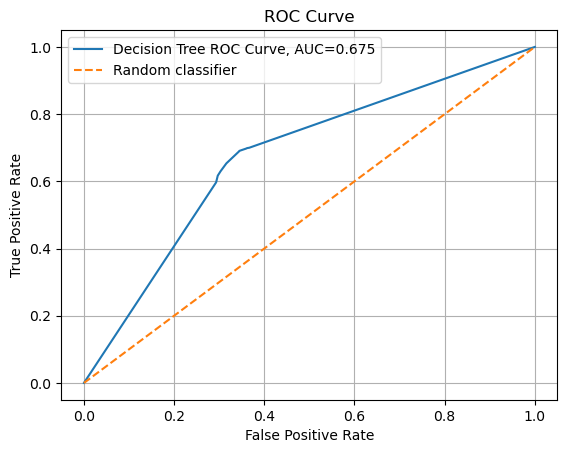

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

def manual_roc_curve(tree, test, thresholds):
    Y_true = test["Diabetes_binary"]
    TPR = []
    FPR = []
    for i in thresholds:
        roc_y = pd.DataFrame(np.zeros((len(test), 2)), columns = ["Diabetes_predict", "Diabetes_scores"])
        predict(tree, test, roc_y, i)
        TPR.append(true_positive_rate(Y_true, roc_y["Diabetes_predict"]))
        FPR.append(false_positive_rate(Y_true, roc_y["Diabetes_predict"]))
    TPR.append(0)
    FPR.append(0)

    legend_label = roc_auc_score(Y_true, roc_y["Diabetes_scores"])

    plt.plot(FPR, TPR, label = f"Decision Tree ROC Curve, AUC={round(legend_label, 3)}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid()
    plt.legend()
    plt.show()

thresholds = [i/10 for i in range(0, 10, 1)]
manual_roc_curve(tree, test, thresholds)

# 3. Multiple Runs Loop

Now that we have a working Decision Tree, we can use it on different splited training and testing data to visualise its variability.
This has been done through a timed loop, made here for 10 runs.

N.B. For easier comparison, and to go faster, we used the `scikit_learn`function `roc_auc_score` and `roc_curve` for ROC.

In [19]:
import time

runTimes = []
runAcc = []
runAUC = []
runSpec = []
randseed = 137
dfDeepCopy = df.copy()
for i in range(10):
    df = dfDeepCopy.copy()
    print("Running... run number: ", i)
    # start timer
    start_time = time.time()
    # data split
    SEED = randseed+i
    train, test = split_train_test(df, SEED)
    train = train.reset_index(drop = True)
    test = test.reset_index(drop = True)
    # DT training
    features_list = header[1:]
    numerical_columns = df.describe().columns
    tree = decision_tree(train, features_list, numerical_columns)
    # DT predictions (testing)
    y_predict = pd.DataFrame(np.zeros((len(test), 2)), columns=["Diabetes_predict", "Diabetes_scores"])
    predict(tree, test, y_predict)
    Y_true = test["Diabetes_binary"]
    Y_score = y_predict["Diabetes_scores"]
    # evaluation    
    thisAcc = accuracy(test["Diabetes_binary"], y_predict["Diabetes_predict"].astype(bool))
    thisSpec = specificity(test["Diabetes_binary"], y_predict["Diabetes_predict"].astype(bool))
    ## roc
    fpr, tpr, thresh = roc_curve(Y_true, Y_score)
    roc_auc  = roc_auc_score(Y_true, Y_score)
    # stop timer
    thisRunTime = time.time() - start_time
    # registering runtime, accuracy and specificity
    runTimes.append(thisRunTime)
    runAcc.append(thisAcc)
    runAUC.append(roc_auc)
    runSpec.append(thisSpec)
    # to show progress
    print("Run time: ", thisRunTime)
    print("Accuracy: ", thisAcc)
    print("AUC: ", roc_auc)
    print("Specificity: ", thisSpec)

Running... run number:  0
Run time:  20.215854167938232
Accuracy:  0.6535115637598132
AUC:  0.6556742314949505
Specificity:  0.6380167637448502
Running... run number:  1
Run time:  19.988447904586792
Accuracy:  0.6636254331989533
AUC:  0.6653527284124404
Specificity:  0.6548007374840448
Running... run number:  2
Run time:  20.200200080871582
Accuracy:  0.652097036565528
AUC:  0.6569729400798904
Specificity:  0.6424667133847232
Running... run number:  3
Run time:  20.40605592727661
Accuracy:  0.681660654926091
AUC:  0.6893195981373622
Specificity:  0.6637677093561509
Running... run number:  4
Run time:  21.730138063430786
Accuracy:  0.6586038616592405
AUC:  0.6566652906163442
Specificity:  0.6587809629835791
Running... run number:  5
Run time:  20.367666959762573
Accuracy:  0.6440342315581017
AUC:  0.6471922128990146
Specificity:  0.6552012254560646
Running... run number:  6
Run time:  20.53007197380066
Accuracy:  0.6790437796166632
AUC:  0.6837896206173378
Specificity:  0.6946554149085

In [20]:
print("For run times:")
std_sample = np.std(runTimes, ddof = 1)
sample_mean = np.mean(runTimes)
print("Sample std:", std_sample)
print("Sample mean:", sample_mean)

print("For AUC:")
std_sample = np.std(runAUC, ddof = 1)
sample_mean = np.mean(runAUC)
print("Sample std:", std_sample)
print("Sample mean:", sample_mean)

print("For specificity:")
std_sample = np.std(runSpec, ddof = 1)
sample_mean = np.mean(runSpec)
print("Sample std:", std_sample)
print("Sample mean:", sample_mean)

print("For accuracy:")
std_sample = np.std(runAcc, ddof = 1)
sample_mean = np.mean(runAcc)
print("Sample std:", std_sample)
print("Sample mean:", sample_mean)

For run times:
Sample std: 0.5021812773438977
Sample mean: 20.525998711586
For AUC:
Sample std: 0.01293288533943425
Sample mean: 0.6643228477092021
For specificity:
Sample std: 0.019641743498369314
Sample mean: 0.6626095512810432
For accuracy:
Sample std: 0.011540566040079607
Sample mean: 0.6610580663413255
